In [1]:
import sys
import os
def get_FACEGroup_Directory():
    """Get the path of the 'FACEGroup-Feasible-and-Actionable-Counterfactual-Explanations-for-Group-Fairness-Auditing' directory."""
    current_dir = os.getcwd()
    target_dir = 'FACEGroup-Feasible-and-Actionable-Counterfactual-Explanations-for-Group-Fairness-Auditing'
    
    while os.path.basename(current_dir) != target_dir:
        current_dir = os.path.dirname(current_dir)
        if current_dir == os.path.dirname(current_dir):
            return None
        
    return current_dir

def get_system_slash():
    """Get the system-specific directory separator."""
    return os.sep

FACEGroup_DIR = get_FACEGroup_Directory()
sys.path.append(FACEGroup_DIR)
sep = get_system_slash()
sys.path.append(FACEGroup_DIR + get_system_slash() + 'src')
from main import *

2025-03-14 17:51:33.811497: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-14 17:51:33.811538: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-14 17:51:33.812627: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-14 17:51:33.818231: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-14 17:51:34.374421: W tensorflow/compiler/tf2

In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
datasetName = 'Adult'

# Decide Epsilon parameter

In [ ]:
from main import *
from utils import *
from test_utils import *
import math
from scipy.spatial import distance

tp = 0.5
skip_bandwith_calculation=True
datasetName = 'Adult'
bandwith_approch = "mean_scotts_rule"
classifier = "xgb"
skip_model_training = True


data, data_np, X, FEATURE_COLUMNS, TARGET_COLUMNS, kernel, model = initialize_FACEGroup_attributes(datasetName=datasetName, skip_bandwith_calculation=True,\
                            bandwith_approch=bandwith_approch, classifier=classifier, skip_model_training=skip_model_training)

results = {}
start=0.1
step=0.1

distances = distance.cdist(data[FEATURE_COLUMNS], data[FEATURE_COLUMNS], 'euclidean')
max_distances_in_the_dataset = math.ceil(np.max(distances))
print(f"Max distance in the dataset: {max_distances_in_the_dataset}")

for e in np.arange(start, 0.7, step):
    e = round(e, 1)
    print(f"Processing epsilon: {e}")
    if os.path.exists(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Distances.pkl") and os.path.exists(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Graphs{sep}Graph_{e}.pkl"):
        graph = pk.load(open(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Graphs{sep}Graph_{e}.pkl", "rb"))
        fACEGroup = FACEGroup(data_np, kernel, FEATURE_COLUMNS, TARGET_COLUMNS, e, model)
        fACEGroup.set_graph(graph)

        print("Loading distances from file ...")
        distances = pk.load(open(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Distances.pkl", "rb"))
    else:
        fACEGroup = FACEGroup(data_np, kernel, FEATURE_COLUMNS, TARGET_COLUMNS, e, model)
        feasibility_constraints = utils.getFeasibilityConstraints(FEATURE_COLUMNS, dataset_name=datasetName)

        start_time = time.time()
        dng_obj = GraphBuilder(feasibility_constraints, FEATURE_COLUMNS, X, kernel, exclude_columns=True)
        distances, graph, densities = dng_obj.compute_pairwise_distances_within_subgroups_and_graph(datasetName, data[FEATURE_COLUMNS], e, feasibility_constraints, None)
        end_time = time.time()
        execution_time = end_time - start_time
        print("Distances and graph initialization: ", execution_time, " seconds")

        if not os.path.exists(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Graphs{sep}"):
            os.makedirs(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Graphs{sep}")
        
        if not os.path.exists(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Densities{sep}"):
            os.makedirs(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Densities")

        if not os.path.exists(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Distances.pkl"):
            pk.dump(distances, open(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Distances.pkl", "wb"))

        pk.dump(graph, open(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Graphs{sep}Graph_{e}.pkl", "wb"))
        pk.dump(densities, open(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Densities{sep}Densities_{e}.pkl", "wb"))

    try:
        print(f"Max possible distance considered in graph: {np.max([edge[2]['distance'] for edge in graph.edges(data=True)])}")
    except:
        print(f"Max possible distance considered in graph: {0}")

    strongly_connected_components = list(nx.strongly_connected_components(graph))
    weakly_connected_components = list(nx.weakly_connected_components(graph))

    connected_nodes = sum(1 for node, degree in graph.degree() if degree > 0)

    graph_density = nx.density(graph)

    d = {"strongly_connected_components": len(strongly_connected_components), "weakly_connected_components": len(weakly_connected_components),
        "Percentage_of_connected_nodes": (connected_nodes/len(X))*100, "Density": graph_density * 100}
    print(d,"\n")
    results[e] = d

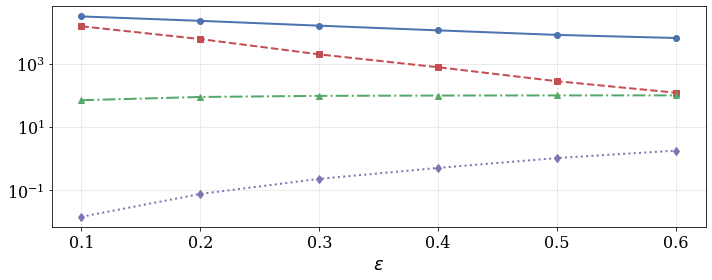

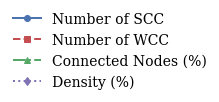

In [ ]:
import matplotlib.pyplot as plt

color_scc = '#4C72B0'  # Muted Blue
color_wcc = '#C44E52'  # Muted Red
color_nodes = '#55A868'  # Muted Green
color_density = '#8172B3'  # Muted Purple
plt.rcParams.update({"font.family": "serif"})

epsilons = list(results.keys())
strongly_connected_components = [results[k]["strongly_connected_components"] for k in epsilons]
weakly_connected_components = [results[k]["weakly_connected_components"] for k in epsilons]
node_connectivity = [results[k]["Percentage_of_connected_nodes"] for k in epsilons]
edge_connectivity = [results[k]["Density"] for k in epsilons]

fig, ax = plt.subplots(figsize=(10, 4))
line1, = ax.plot(epsilons, strongly_connected_components, marker='o', linestyle='-', color=color_scc, label="Number of SCC", linewidth=2, markersize=6)
line2, = ax.plot(epsilons, weakly_connected_components, marker='s', linestyle='--', color=color_wcc, label="Number of WCC", linewidth=2, markersize=6)
line3, = ax.plot(epsilons, node_connectivity, marker='^', linestyle='-.', color=color_nodes, label="Connected Nodes (%)", linewidth=2, markersize=6)
line4, = ax.plot(epsilons, edge_connectivity, marker='d', linestyle=':', color=color_density, label="Density (%)", linewidth=2, markersize=6)

ax.set_xlabel(r"$\varepsilon$", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_yscale('log')
ax.set_xticks(epsilons)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()

fig.savefig(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}figs{sep}{datasetName}_connectivity_plot_no_legend.pdf", dpi=300)

# Create a separate figure for the legend
fig_legend = plt.figure(figsize=(2, 1))
ax_legend = fig_legend.add_subplot(111)
ax_legend.legend([line1, line2, line3, line4], [line.get_label() for line in [line1, line2, line3, line4]], loc='center', fontsize=14, frameon=False)
ax_legend.axis('off')

fig_legend.tight_layout(pad=1.0)
fig_legend.savefig(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}figs{sep}{datasetName}_legend_e.pdf", bbox_inches='tight', dpi=300)
plt.show()

In [9]:
epsilon = 0.4

# AUC metrics

### (k) AUC related metrics

In [10]:
from test_utils import *
upper_limit_for_k = 12 # k0 = 12
max_d = 1.05 # d0
nice_numbers(1, upper_limit_for_k, 4), nice_numbers(0.1, 2, 12, score='d')

(array([ 1,  5,  9, 13]),
 array([0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7, 1.9, 2.1, 2.3]))

In [ ]:
from metrics import *
saturation_points_k, cov_for_saturation_points_k, auc_matrix_k = kAUC(datasetName=datasetName, epsilon=epsilon,\
    group_identifier='sex', group_identifier_value=None, upper_limit_for_k=upper_limit_for_k,\
    lower_limit_range_for_d=0.1, upper_limit_range_for_d=2, stepsd=12, stepsk=4, skip_FACEGroup_calculation=True, representation=16)

In [9]:
saturation_points_k

{1: {'0.0': 1.1, '1.0': 1.3},
 5: {'0.0': 1.1, '1.0': 1.1},
 9: {'0.0': 1.1, '1.0': 1.1},
 13: {'0.0': 0.7, '1.0': 1.1}}

In [10]:
cov_for_saturation_points_k

{1: {'0.0': 63.07692307692307, '1.0': 65.75342465753424},
 5: {'0.0': 93.84615384615384, '1.0': 97.48858447488584},
 9: {'0.0': 100.0, '1.0': 99.08675799086758},
 13: {'0.0': 100.0, '1.0': 100.0}}

In [11]:
auc_matrix_k

{1: {'0.0': 0.5, '1.0': 0.54},
 5: {'0.0': 0.82, '1.0': 0.85},
 9: {'0.0': 0.9, '1.0': 0.89},
 13: {'0.0': 0.92, '1.0': 0.91}}

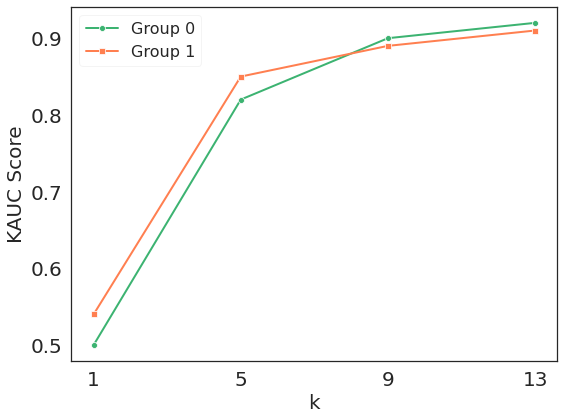

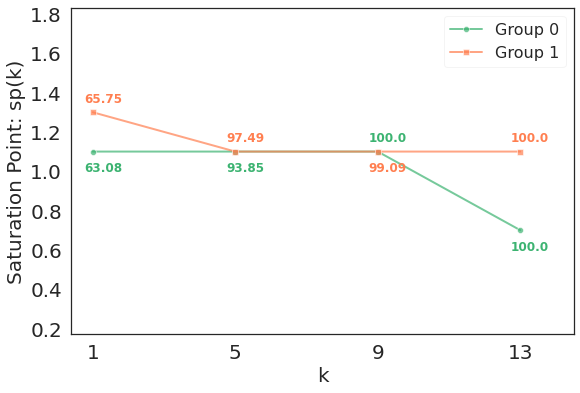

In [12]:
plot_k_or_dAUC('Adult', saturation_points_k, cov_for_saturation_points_k, auc_matrix_k, 'k', expand_right_x_axis=1.5)

### (d) AUC related metrics

In [ ]:
from metrics import *
saturation_points_d, cov_for_saturation_points_d, auc_matrix_d =dAUC(datasetName=datasetName, epsilon=epsilon, verbose=False,\
    group_identifier='sex', group_identifier_value=None, lower_limit_range_for_d=0.1, upper_limit_range_for_d=2,\
          upper_limit_for_k=upper_limit_for_k, stepsd=4, stepsk=12, skip_FACEGroup_calculation=True)

In [15]:
saturation_points_d

{0.1: {'0.0': 6, '1.0': 12},
 0.8: {'0.0': 10, '1.0': 12},
 1.5: {'0.0': 9, '1.0': 12},
 2.2: {'0.0': 9, '1.0': 12}}

In [16]:
cov_for_saturation_points_d

{0.1: {'0.0': 12.307692307692308, '1.0': 12.785388127853881},
 0.8: {'0.0': 100.0, '1.0': 99.31506849315068},
 1.5: {'0.0': 100.0, '1.0': 99.77168949771689},
 2.2: {'0.0': 100.0, '1.0': 99.77168949771689}}

In [17]:
auc_matrix_d

{0.1: {'0.0': 0.1, '1.0': 0.08},
 0.8: {'0.0': 0.89, '1.0': 0.93},
 1.5: {'0.0': 0.93, '1.0': 0.95},
 2.2: {'0.0': 0.93, '1.0': 0.95}}

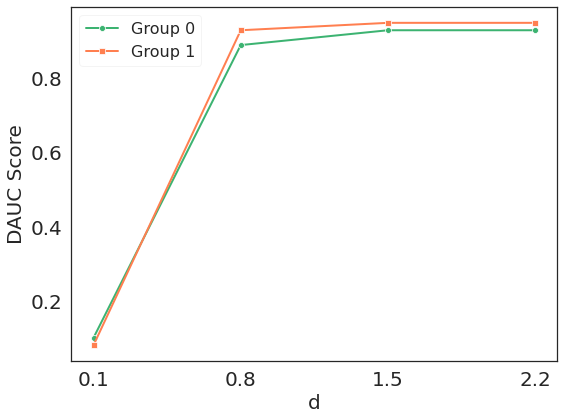

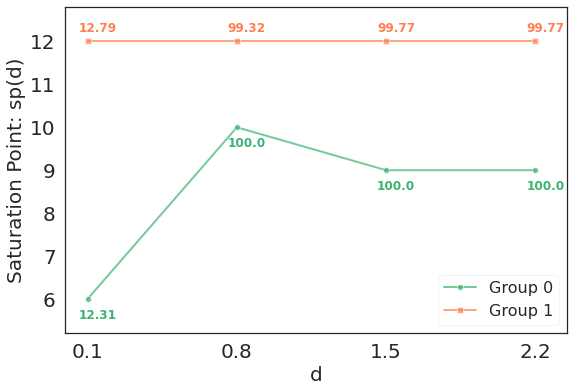

In [18]:
plot_k_or_dAUC("Adult", saturation_points_d, cov_for_saturation_points_d, auc_matrix_d, 'd', expand_right_x_axis=0.15)

### (c) AUC related metrics

In [ ]:
from metrics import *
saturation_points_c, cost_for_saturation_points, auc_matrix_c =cAUC(datasetName=datasetName, epsilon=epsilon, verbose=False,\
    group_identifier='sex', group_identifier_value=None, coverage_values = [0.25, 0.5, 0.75, 1], upper_limit_for_k=25,\
    skip_FACEGroup_calculation=True, skip_bandwith_calculation=True, skip_graph_creation=True, skip_distance_calculation=True)

In [ ]:
saturation_points_c

{0.25: {'group_0': 12, 'group_1': 20},
 0.5: {'group_0': 18, 'group_1': 23},
 0.75: {'group_0': 22, 'group_1': 25},
 1: {'group_0': 16, 'group_1': 20}}

In [ ]:
cost_for_saturation_points

{0.25: {'group_0': 0.144287109375, 'group_1': 0.1275634765625},
 0.5: {'group_0': 0.2259521484375, 'group_1': 0.207763671875},
 0.75: {'group_0': 0.289306640625, 'group_1': 0.303466796875},
 1: {'group_0': 0.55419921875, 'group_1': 1.4013671875}}

In [ ]:
auc_matrix_c

{0.25: {'group_0': 0.10297804935918732, 'group_1': 0.10537096636810271},
 0.5: {'group_0': 0.17142028267821544, 'group_1': 0.16951706494419422},
 0.75: {'group_0': 0.25038654397242316, 'group_1': 0.24988783182743893},
 1: {'group_0': 0.5618923643156871, 'group_1': 0.7232287475081216}}

# Testing for different Classifiers

In [ ]:
results = main_cost_constrained_GCFEs(epsilon=epsilon, datasetName=datasetName, group_identifier='sex', classifier='lr',
                            k=upper_limit_for_k, max_d=max_d, k_selection_method="accross_all_ccs", cost_function = "max_vector_distance",
                            skip_model_training=True, skip_graph_creation=True)[0]

In [ ]:
results = main_cost_constrained_GCFEs(epsilon=epsilon, datasetName=datasetName, group_identifier='sex', classifier='xgb',
                            k=upper_limit_for_k, max_d=max_d, k_selection_method="accross_all_ccs", cost_function = "max_vector_distance",
                            skip_model_training=True, skip_graph_creation=True)[0]

In [ ]:
results = main_cost_constrained_GCFEs(epsilon=epsilon, datasetName=datasetName, group_identifier='sex', classifier='dnn',
                            k=upper_limit_for_k, max_d=max_d, k_selection_method="accross_all_ccs", cost_function = "max_vector_distance",
                            skip_model_training=True, skip_graph_creation=True)[0]

# Freq Itemsets Data

In [ ]:
from main import *

FACEGroup, graph, distances, data, data_np, data_df_copy, attr_col_mapping, normalized_group_identifer_value, numeric_columns, positive_points,\
      Factuals, Factuals_by_group, node_connectivity, edge_connectivity, feasibility_constraints = initialize_FACEGroup(epsilon=0.4,\
             datasetName='Adult', group_identifier='sex', bandwith_approch="mean_scotts_rule", classifier='xgb',\
				 skip_model_training=True, skip_distance_calculation=True, skip_graph_creation=True, skip_bandwith_calculation=True)

In [20]:
factual_keys_by_group = {}
for key, value in Factuals_by_group.items():
    factual_keys_by_group[key] = list(value.keys())
group_identifier='sex'
subgroups = utils.get_subgraphs_by_group(graph, data_np, data, attr_col_mapping, group_identifier, normalized_group_identifer_value, numeric_columns)
weakly_connected_components = {}
subgroup_nodes = {}
for group, subgraph in subgroups.items():
    weakly_connected_components[group] = list(nx.weakly_connected_components(subgraph))
    subgroup_nodes[group] = list(subgraph.nodes())
    print(f"Group {group} has {len(weakly_connected_components[group])} weakly connected components")
wcc_factuals_candidate_cfes = {}
i = 0
for group, wcc_list in weakly_connected_components.items():
    wcc_factuals_candidate_cfes[group] = {}
    for wcc in wcc_list:
        if any(node in factual_keys_by_group[group] for node in wcc) and any(node in positive_points for node in wcc):
            wcc_factuals_candidate_cfes[group][i] = {
                'Factuals': [node for node in wcc if node in factual_keys_by_group[group]],
                'Candidate_counterfactuals': [node for node in wcc if node in positive_points]
            }
        i += 1

Group 0.0 has 410 weakly connected components
Group 1.0 has 365 weakly connected components


In [21]:
from mlxtend.frequent_patterns import apriori
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd

def get_original_based_on_indexes(data, indexes):
    return data.iloc[list(indexes)]

def preprocess_dataset_for_freq_itemsets(datasetName, data_for_apriori):
    df = data_for_apriori.copy()

    bins_dict = {}
    if datasetName == "Adult":
        bins_dict = {
            'age': [15, 25, 35, 45, 55, 65, 100],
            'workclass': [0, 3, 6, 8],
            'education': [0, 5, 10, 15, 20], 
            'education-num': [1, 4, 8, 12, 15],
            'hours-per-week': [1, 20, 40, 60, 80, 99],
            'occupation': [0, 3, 6, 9, 12, 14],
            'capital-gain': [0, 5000, 10000, 15000, 99999],
            'capital-loss': [0, 1000, 2000, 3000, 4356]
        }
    elif datasetName == "Student":
        bins_dict = {
            'age': [15, 17, 20, 22],
            'absences': [0, 5, 10, 15, 20, 25, 30, 35]
        }
    
    # Binning
    for col, bins in bins_dict.items():
        labels = [f"{col}: [{bins[i]}-{bins[i+1]}]" for i in range(len(bins)-1)]
        df[col] = pd.cut(df[col], bins=bins, labels=labels, include_lowest=True)

    if datasetName == "Adult":
        categorical_cols = ['marital-status',
                        'relationship', 'sex', 'race_0', 'race_1', 'race_2', 'race_3', 'race_4']
    elif datasetName == "Student":
        categorical_cols = ['school', 'sex', 'address','famsize', 'Pstatus', 'Medu', 'Fedu',
                'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities',
                'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
                'Walc', 'health', 'M_job_0', 'M_job_1', 'M_job_2', 'M_job_3', 'M_job_4', 'F_job_0',
                'F_job_1', 'F_job_2', 'F_job_3', 'F_job_4', 'reason_0', 'reason_1', 'reason_2', 'reason_3',
                'guardian_0', 'guardian_1', 'guardian_2']

    for col in df.columns:
        if col in categorical_cols:
            df[col] = col + ": " + df[col].astype(str)
        else:
            df[col] = df[col].astype(str)
    return df

def frequent_itemsets(df, min_support=0.6):
    transactions = df.apply(lambda row: row.tolist(), axis=1).tolist()

    # Encode the transactions into a format suitable for Apriori
    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    df_encoded = pd.DataFrame(te_ary, columns=te.columns_)
    frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)

    # Format Output for Readability
    frequent_itemsets['itemsets'] = frequent_itemsets['itemsets'].apply(lambda x: ', '.join(x))
    return frequent_itemsets

def get_descriptions_per_wcc(datasetName, wcc_Factuals_candidateCfes, group_id, min_support=1):
    descriptions = {}
    for cc_id in wcc_Factuals_candidateCfes[group_id]:
        wcc = wcc_Factuals_candidateCfes[group_id][cc_id]
        descriptions[cc_id] = {"Factuals": [], "Candidate_counterfactuals": []}

        ## Run on Factuals
        data_for_apriori_Factuals = get_original_based_on_indexes(data_df_copy, wcc['Factuals'])
        preprocessed_df_for_apriori_Factuals = preprocess_dataset_for_freq_itemsets(datasetName, data_for_apriori_Factuals)
        population_frequent_itemsets_factuals = frequent_itemsets(preprocessed_df_for_apriori_Factuals, min_support=min_support)
        unique_descriptions_Factuals = set([v.split(",")[0] for v in list(population_frequent_itemsets_factuals[population_frequent_itemsets_factuals['support'] >= min_support]['itemsets'])])
        descriptions[cc_id]["Factuals"] = unique_descriptions_Factuals

        ## Run on Candidate_counterfactuals points
        data_for_apriori_candidate_cfes = get_original_based_on_indexes(data_df_copy, wcc['Candidate_counterfactuals'])
        preprocessed_df_for_apriori_candidate_cfes = preprocess_dataset_for_freq_itemsets(datasetName, data_for_apriori_candidate_cfes)
        population_frequent_itemsets_candidate_cfes = frequent_itemsets(preprocessed_df_for_apriori_candidate_cfes, min_support=min_support)
        unique_descriptions_candidate_cfes = set([v.split(",")[0] for v in list(population_frequent_itemsets_candidate_cfes[population_frequent_itemsets_candidate_cfes['support'] >= min_support]['itemsets'])])
        descriptions[cc_id]["Candidate_counterfactuals"] = unique_descriptions_candidate_cfes
    return descriptions

def get_descriptions_for_group(datasetName, group, group_id, min_support=1):
    data_for_apriori = get_original_based_on_indexes(data_df_copy, group)
    preprocessed_df_for_apriori = preprocess_dataset_for_freq_itemsets(datasetName, data_for_apriori)
    population_frequent_itemsets = frequent_itemsets(preprocessed_df_for_apriori, min_support=min_support)
    unique_descriptions = set([v.split(",")[0] for v in list(population_frequent_itemsets[population_frequent_itemsets['support'] >= min_support]['itemsets'])])
    return unique_descriptions

##### Compare the descriptions between Factuals and Candidate_counterfactuals points #####
def compare_factuals_candidate_cfes(descriptions):
    comparison_results = {}

    for cc_id, groups in descriptions.items():
        factuals_set = groups['Factuals']
        candidate_cfe_set = groups['Candidate_counterfactuals']
        
        changes = []
        missing_in_candidate_cfes = []
        same_values = []

        # Convert each feature-value pair into a dictionary for easy lookup
        factuals_dict = {v.split(": ")[0]: v.split(": ")[1] for v in factuals_set if ": " in v}
        candidate_cfes_dict = {v.split(": ")[0]: v.split(": ")[1] for v in candidate_cfe_set if ": " in v}

        # Check differences and similarities
        all_features = set(factuals_dict.keys()).union(set(candidate_cfes_dict.keys()))

        for feature in all_features:
            factual_value = factuals_dict.get(feature, None)
            candidate_cfe_value = candidate_cfes_dict.get(feature, None)

            if factual_value and candidate_cfe_value:
                if factual_value != candidate_cfe_value:  
                    changes.append(f"{feature}: {factual_value} → {candidate_cfe_value}")
                else:  
                    same_values.append(f"{feature}: {factual_value}")
            elif factual_value: 
                missing_in_candidate_cfes.append(f"{feature}: {factual_value} → ?")
            elif candidate_cfe_value: 
                missing_in_candidate_cfes.append(f"{feature}: ? → {candidate_cfe_value}")

        comparison_results[cc_id] = {
            "changes": changes,
            "same_values": same_values,
            "missing_in_candidate_cfes": missing_in_candidate_cfes
        }
    
    return comparison_results

##### Present the descriptions between Factuals and Candidate_counterfactuals points #####
def format_comparison_output(comparison_results):
    formatted_descriptions = {}

    for cc_id, groups in comparison_results.items():
        same_values = [f"{v.split(': ')[0]}: {v.split(': ')[1]}" for v in groups["same_values"]]
        changes = groups["changes"] + groups["missing_in_candidate_cfes"]
        description_str = f"  Description: {', '.join(same_values)}" if same_values else "Description: No common features"
        changes_str = f"    Changes: {', '.join(changes)}" if changes else ""
        formatted_descriptions[cc_id] = f"{description_str}\n{changes_str}".strip()
    return formatted_descriptions

## Group Descriptions

In [22]:
group_descriptions = {}
for key, subgroup_nodes_ in subgroup_nodes.items():
    group_descriptions[key] = get_descriptions_for_group("Adult", subgroup_nodes_, key, min_support=1)
group_descriptions

{0.0: {'sex: 0'}, 1.0: {'sex: 1'}}

## Subroup Descriptions

In [10]:
mapping_dict = {
    "Adult": {
        "race": {
            "0": "White",
            "1": "Asian-Pac-Islander",
            "2": "Amer-Indian-Eskimo",
            "3": "Other",
            "4": "Black"
        }
    }
}
def replace_and_filter_categories(desc_set, dataset_name, mapping_dict):
    updated_set = set()
    for item in desc_set:
        parts = item.split(": ")
        if len(parts) == 2 and "_" in parts[0]:  
            field, value = parts
            feature, key = field.split("_")
            if dataset_name in mapping_dict and feature in mapping_dict[dataset_name] and key in mapping_dict[dataset_name][feature]:
                readable_value = mapping_dict[dataset_name][feature][key]
                if value.strip() == "1.0":  # Keep only the attribute where the one-hot value is 1.0
                    updated_set.add(f"{feature}: {readable_value}")
        else:
            updated_set.add(item)  # Keep non-matching items unchanged
    return updated_set

# Apply transformation to descriptions
for group_id, wcc_FN_positive_nodes in wcc_factuals_candidate_cfes.items():
    print(f"Group {group_id}")
    descriptions = get_descriptions_per_wcc("Adult", wcc_factuals_candidate_cfes, group_id, min_support=1)
    
    for cc_id, desc in descriptions.items():
        print(f"CC {cc_id}:")
        print(replace_and_filter_categories(desc["Factuals"], "Adult", mapping_dict))
        print("\n")

Group 0.0
CC 0:
{'race: Black', 'sex: 0', 'capital-gain: [0-5000]'}


CC 1:
{'relationship: 5', 'sex: 0', 'capital-loss: [0-1000]', 'capital-gain: [0-5000]', 'race: Amer-Indian-Eskimo', 'hours-per-week: [20-40]', 'marital-status: 2'}


CC 8:
{'relationship: 5', 'sex: 0', 'capital-loss: [0-1000]', 'capital-gain: [0-5000]', 'workclass: [3-6]', 'race: Asian-Pac-Islander', 'marital-status: 2'}


CC 226:
{'education: [0-5]', 'sex: 0', 'occupation: [9-12]', 'capital-gain: [0-5000]', 'age: [25-35]', 'education-num: [4-8]', 'workclass: [3-6]', 'capital-loss: [2000-3000]', 'hours-per-week: [40-60]', 'marital-status: 5', 'relationship: 1', 'race: Black'}


Group 1.0
CC 410:
{'race: Black', 'sex: 1', 'capital-gain: [0-5000]'}


CC 412:
{'relationship: 0', 'capital-gain: [0-5000]', 'race: Amer-Indian-Eskimo', 'sex: 1', 'marital-status: 2'}


CC 413:
{'relationship: 0', 'capital-loss: [0-1000]', 'capital-gain: [0-5000]', 'sex: 1', 'race: Asian-Pac-Islander', 'marital-status: 2'}


CC 415:
{'relatio

## Changes, same, and missing values between factuals and candidate counterfactuals

In [ ]:
for group_id, wcc_factuals_candidate_cfes_nodes in wcc_factuals_candidate_cfes.items():
    print(f"Group {group_id}")
    descriptions = get_descriptions_per_wcc("Adult", wcc_factuals_candidate_cfes, group_id, min_support=1)
    desc = compare_factuals_candidate_cfes(descriptions)
    for wcc, values in desc.items():
        print(f"WCC {wcc}:")
        print(values)
    print("\n")

Group 0.0
WCC 0:
{'changes': [], 'same_values': ['race_0: 0.0', 'race_2: 0.0', 'race_1: 0.0', 'sex: 0', 'race_4: 1.0', 'race_3: 0.0'], 'missing_in_candidate_cfes': ['capital-gain: [0-5000] → ?']}
WCC 1:
{'changes': [], 'same_values': ['race_0: 0.0', 'race_2: 1.0', 'race_1: 0.0', 'sex: 0', 'race_4: 0.0', 'race_3: 0.0'], 'missing_in_candidate_cfes': ['capital-gain: [0-5000] → ?', 'capital-loss: [0-1000] → ?', 'relationship: 5 → ?', 'marital-status: 2 → ?', 'hours-per-week: [20-40] → ?']}
WCC 8:
{'changes': [], 'same_values': ['capital-gain: [0-5000]', 'race_0: 0.0', 'race_2: 0.0', 'race_1: 1.0', 'sex: 0', 'race_4: 0.0', 'race_3: 0.0'], 'missing_in_candidate_cfes': ['workclass: [3-6] → ?', 'relationship: 5 → ?', 'marital-status: 2 → ?', 'capital-loss: [0-1000] → ?']}
WCC 226:
{'changes': ['capital-loss: [2000-3000] → [1000-2000]', 'hours-per-week: [40-60] → [20-40]', 'age: [25-35] → [15-25]', 'marital-status: 5 → 4'], 'same_values': ['race_0: 0.0', 'occupation: [9-12]', 'sex: 0', 'capital

# Graph Structure and aWWCs for selected e

In [ ]:
from test_utils import get_graph_stats
get_graph_stats(epsilon=0.1, datasetName='Adult', group_identifier='sex', bandwith_approch="mean_scotts_rule", classifier='xgb')

Get bandwidth for Adult...
Bandwidth: 0.04465720232058467
Fitting kernel...


{0.0: {'num_nodes': 14320,
  'num_strongly_connected_components': 12057,
  'num_weakly_connected_components': 6663,
  'density': '0.02'},
 1.0: {'num_nodes': 27499,
  'num_strongly_connected_components': 19451,
  'num_weakly_connected_components': 8688,
  'density': '0.03'}}

In [90]:
from test_utils import get_graph_stats
get_graph_stats(epsilon=0.4, datasetName='Adult', group_identifier='sex', bandwith_approch="mean_scotts_rule", classifier='xgb')

Get bandwidth for Adult...
Bandwidth: 0.04465720232058467
Fitting kernel...


{0.0: {'num_nodes': 14320,
  'num_strongly_connected_components': 5358,
  'num_weakly_connected_components': 410,
  'density': '0.49'},
 1.0: {'num_nodes': 27499,
  'num_strongly_connected_components': 6039,
  'num_weakly_connected_components': 365,
  'density': '1.03'}}

In [14]:
from test_utils import get_graph_stats
get_graph_stats(epsilon=0.6, datasetName='Adult', group_identifier='sex', bandwith_approch="mean_scotts_rule", classifier='xgb')

Get bandwidth for Adult...
Bandwidth: 0.04465720232058467
Fitting kernel...


{0.0: {'num_nodes': 14320,
  'num_strongly_connected_components': 3200,
  'num_weakly_connected_components': 63,
  'density': '1.77'},
 1.0: {'num_nodes': 27499,
  'num_strongly_connected_components': 3327,
  'num_weakly_connected_components': 58,
  'density': '3.63'}}

In [11]:
import networkx as nx
import pickle


with open(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Graphs{sep}Graph_{epsilon}.pkl", "rb") as file:
    graph = pickle.load(file)

strongly_connected_components = list(nx.strongly_connected_components(graph))
weakly_connected_components = list(nx.weakly_connected_components(graph))

print("Strongly connected components:", len(strongly_connected_components))
print("Weakly connected components:", len(weakly_connected_components))


import json
with open(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}cost_constrained_GCFEs{sep}results_{datasetName}_eps{epsilon}_k_{upper_limit_for_k}_cost_function_max_vector_distance_d_{max_d}_kmethod_accross_all_ccs.json", "r") as file:
    results = json.load(file)

Strongly connected components: 11397
Weakly connected components: 775


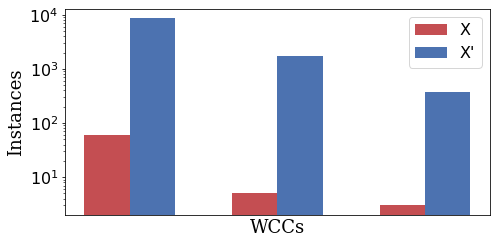

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-muted')

bar_width = 0.4
fig, ax = plt.subplots(figsize=(7, 3.5))

color_factuals = '#C44E52'  # Muted red
color_cfes = '#4C72B0'  # Muted blue

stats = results['Graph Stats']['0.0']
aWCCs = set()
r0 = results['0.0']

for fn in r0:
    if fn in ['Coverage', 'Avg. distance', 'Avg. path cost', 'Median distance', 'Median path cost']:
        continue
    aWCCs.add(f"{r0[fn]['cfe_cc']}")

cc_names = [cc for cc in stats if cc.isdigit()]
num_cc = len(cc_names)

bar_gap = 0.5
center_poss = []
labels_added = {'candidate_cfes': False, 'factuals': False}

for j, cc in enumerate(cc_names):
    if cc not in aWCCs:
        continue
    candidate_cfes = stats[cc]['candidate_cfes']
    factuals = stats[cc]['factuals']

    center_pos = j * (2 * bar_width + bar_gap)
    r1 = center_pos - bar_width / 2
    r2 = center_pos + bar_width / 2
    ax.bar(r1, factuals, color=color_factuals, width=bar_width, label='X' if not labels_added['factuals'] else "", zorder=3)
    labels_added['factuals'] = True

    ax.bar(r2, candidate_cfes, color=color_cfes, width=bar_width, label="X'" if not labels_added['candidate_cfes'] else "", zorder=3)
    labels_added['candidate_cfes'] = True

    center_poss.append((r1 + r2) / 2)

ax.set_xticks([])
ax.set_xlabel('WCCs', fontsize=18, fontfamily='serif')
ax.set_ylabel('Instances', fontsize=18, fontfamily='serif')

ax.set_yscale('log')
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.legend(fontsize=16, frameon=True)
plt.tight_layout()
plt.show()
fig.savefig(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}figs{sep}ccs_candidate_cfes_factuals_g0.pdf", dpi=300)

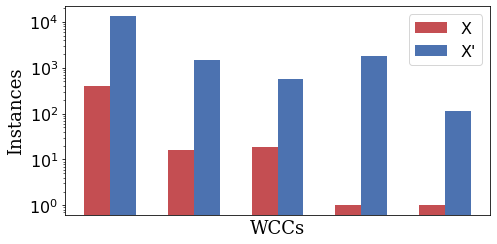

In [ ]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-muted')
bar_width = 0.4
fig, ax = plt.subplots(figsize=(7, 3.5))

color_factuals = '#C44E52'  # Muted red
color_cfes = '#4C72B0'  # Muted blue

stats = results['Graph Stats']['1.0']
aWCCs = set()
r0 = results['1.0']

for fn in r0:
    if fn in ['Coverage', 'Avg. distance', 'Avg. path cost', 'Median distance', 'Median path cost']:
        continue
    aWCCs.add(f"{r0[fn]['cfe_cc']}")

cc_names = [cc for cc in stats if cc.isdigit()]
num_cc = len(cc_names)

bar_gap = 0.5
center_poss = []
labels_added = {'candidate_cfes': False, 'factuals': False}

for j, cc in enumerate(cc_names):
    if cc not in aWCCs:
        continue
    candidate_cfes = stats[cc]['candidate_cfes']
    factuals = stats[cc]['factuals']

    center_pos = j * (2 * bar_width + bar_gap)
    r1 = center_pos - bar_width / 2
    r2 = center_pos + bar_width / 2


    ax.bar(r1, factuals, color=color_factuals, width=bar_width, label='X' if not labels_added['factuals'] else "", zorder=3)
    labels_added['factuals'] = True

    ax.bar(r2, candidate_cfes, color=color_cfes, width=bar_width, label="X'" if not labels_added['candidate_cfes'] else "", zorder=3)
    labels_added['candidate_cfes'] = True

    center_poss.append((r1 + r2) / 2)

ax.set_xticks([])
ax.set_xlabel('WCCs', fontsize=18, fontfamily='serif')
ax.set_ylabel('Instances', fontsize=18, fontfamily='serif')

ax.set_yscale('log')
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.legend(fontsize=16, frameon=True)
plt.tight_layout()
plt.show()
fig.savefig(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}figs{sep}ccs_candidate_cfes_factuals_g1.pdf", dpi=300)